# DPC Station Aggregation

This notebook takes four input CSV files and merges them into a single, per-station aggregated CSV.

**Inputs**

| File | Source | Format |
|------|--------|--------|
| `DPC_latest.csv` | Dipartimento Protezione Civile (national) | long / one row per sensor reading |
| `ARPAE_coastal_latest.csv` | ARPAE Emilia-Romagna | long / one row per sensor reading |
| `ARPAV_latest.csv` | ARPAV Veneto | long / one row per sensor reading |
| `adriatic_coast_stations_aggregated.csv` | already aggregated Adriatic coast | wide / one row per station |

**Goal**: produce **one row per physical station**, holding the most recent value of each
meteorological variable (precipitation, temperature, pressure, wind, humidity).

**Key challenge — the time dimension.** The four sources do *not* share a clock:
their timestamps use different string formats and, more importantly, different time zones
(some are local Italian time, the pre-aggregated file is already in UTC). We therefore
normalise every timestamp to **UTC** before doing anything else, otherwise "the latest
reading" would be wrong across sources.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path(r'D:\StormEngine')
OUTPUTS = Path('.')  # save in the same folder as this notebook (DataAggregation\DPC)

# Assume the raw sources report in Italian local time (CEST = UTC+2 in June).
LOCAL_TZ = 'Europe/Rome'
pd.set_option('display.max_columns', 40)

## Step 1 — Quick look at each file

Before merging we inspect shape, columns and the time window covered by each source.

In [4]:
from pathlib import Path

BASE_DIR = Path(r'D:\StormEngine')

dpc   = pd.read_csv(BASE_DIR / 'DPC_friuli' / 'DPC_latest.csv')
arpae = pd.read_csv(BASE_DIR / 'ARPAE_emilia' / 'ARPAE_coastal_latest.csv')
arpav = pd.read_csv(BASE_DIR / 'ARPAV_veneto' / 'ARPAV_latest.csv')
agg   = pd.read_csv(BASE_DIR / 'MeteoHub_Adriatic' / 'adriatic_coast_stations_aggregated.csv')

for name, df in [('DPC', dpc), ('ARPAE', arpae), ('ARPAV', arpav), ('Adriatic-agg', agg)]:
    print(f'{name:13s} rows={len(df):5d}  stations={df["station_id"].nunique():4d}  cols={list(df.columns)[:6]}...')

DPC           rows= 4644  stations= 340  cols=['station_id', 'sensor_id', 'sensor_code', 'sensor_name', 'quantity', 'unit']...
ARPAE         rows=  277  stations= 158  cols=['station_id', 'sensor_name', 'sensor_code', 'quantity', 'unit', 'dt']...
ARPAV         rows=  621  stations= 245  cols=['station_id', 'sensor_name', 'sensor_code', 'quantity', 'unit', 'dt']...
Adriatic-agg  rows=  122  stations= 122  cols=['station_id', 'sensor_name', 'lat', 'lon', 'codseqst', 'point']...


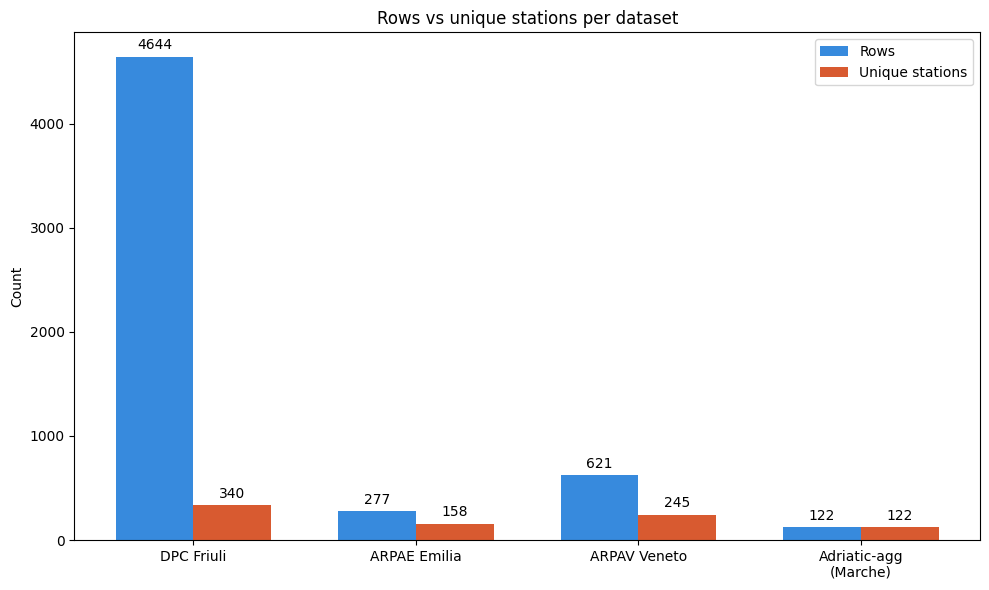

In [5]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['DPC Friuli', 'ARPAE Emilia', 'ARPAV Veneto', 'Adriatic-agg\n(Marche)']
rows     = [4644, 277, 621, 122]
stations = [340, 158, 245, 122]

x = np.arange(len(datasets))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rows, width, label='Rows', color='#378ADD')
bars2 = ax.bar(x + width/2, stations, width, label='Unique stations', color='#D85A30')

ax.set_ylabel('Count')
ax.set_title('Rows vs unique stations per dataset')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()

for bars in (bars1, bars2):
    ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

In [6]:
# Sensor codes present in the three long-format sources
for name, df in [('DPC', dpc), ('ARPAE', arpae), ('ARPAV', arpav)]:
    codes = sorted(df['sensor_code'].dropna().unique().tolist())
    print(f'{name}: {len(codes)} codes -> {codes[:25]}')

DPC: 80 codes -> ['ALLbatt', 'ANreg', 'B', 'BF', 'CAR', 'CV_inf', 'CV_med', 'CV_sup', 'Dv', 'Dv2', 'Dv2max', 'Dv2vett', 'DvMax', 'DvMax1s', 'DvVett', 'IDRO', 'IDRO_2', 'IDRO_3', 'LIV_MARE_IGM42', 'MISxG', 'NIVO', 'P', 'P (RAW)', 'PPWD', 'P_1h']
ARPAE: 4 codes -> ['PREC', 'PRESS', 'TARIA2M', 'VV']
ARPAV: 8 codes -> ['PREC', 'PRESS', 'TARIA2M', 'TARIA5M', 'TARIA8M', 'UMID2M', 'UMID5M', 'UMID8M']


In [7]:
# "sensor codes" equivalent for the wide aggregated source (MeteoHub / Marche)
value_cols = [c for c in agg.columns if c.endswith('_value')]
codes_agg = sorted(c.replace('_value', '') for c in value_cols)
print(f'Adriatic-agg (MeteoHub Marche): {len(codes_agg)} codes -> {codes_agg}')

Adriatic-agg (MeteoHub Marche): 4 codes -> ['PREC', 'PRESS', 'TARIA2M', 'VV']


In [8]:
# Raw time window per source (note: different formats and time zones!)
for name, df in [('DPC', dpc), ('ARPAE', arpae), ('ARPAV', arpav)]:
    print(f'{name:6s}  dt min={df["dt"].min()}   max={df["dt"].max()}')
print('Adriatic-agg sample dt:', agg['PREC_dt'].dropna().iloc[0])

DPC     dt min=2026-06-21 15:45:00   max=2026-06-21 16:30:00
ARPAE   dt min=2026-06-21T12:00:00   max=2026-06-21T15:30:00
ARPAV   dt min=2026-06-21T16:00:00   max=2026-06-21T17:00:00
Adriatic-agg sample dt: 2026-06-21 16:00:00+00:00


Observations:
* DPC, ARPAE and ARPAV are **long format**: each row is one sensor reading, with a `sensor_code`.
* The Adriatic file is already **wide / aggregated**, with one `<VAR>_value` / `<VAR>_dt` pair per variable, and its `dt` is already in UTC (`+00:00`).
* DPC has many sensor codes; the others only a handful (`PREC`, `PRESS`, `TARIA2M`, `VV`, humidity...).
* Timestamp **strings differ** (`YYYY-MM-DD HH:MM:SS` vs ISO `T`) and the windows don't overlap, which is exactly why timezone normalisation matters.

## Step 2 — Define a common variable schema

We collapse the many provider-specific sensor codes into a small set of canonical variables.
Codes not in the map are dropped (battery, raw counters, accumulation windows, etc.).

In [9]:
# canonical variable -> set of source sensor_codes that map to it
SENSOR_MAP = {
    'PREC':    {'PREC', 'RR', 'P', 'Prec_5_min'},   # instantaneous precipitation (mm)
    'TARIA2M': {'TARIA2M', 'T', 'TA', 'Tair'},       # air temperature 2m (C)
    'PRESS':   {'PRESS', 'PR', 'Patm'},              # pressure (hPa)
    'VV':      {'VV', 'FF', 'Vv'},                    # wind speed (m/s)
    'UMID2M':  {'UMID2M', 'UR', 'RH'},               # relative humidity 2m (%)
}
# invert to: source_code -> canonical
CODE_TO_VAR = {c: var for var, codes in SENSOR_MAP.items() for c in codes}
CANON_VARS = list(SENSOR_MAP.keys())
CODE_TO_VAR

{'Prec_5_min': 'PREC',
 'PREC': 'PREC',
 'RR': 'PREC',
 'P': 'PREC',
 'TA': 'TARIA2M',
 'Tair': 'TARIA2M',
 'T': 'TARIA2M',
 'TARIA2M': 'TARIA2M',
 'PRESS': 'PRESS',
 'PR': 'PRESS',
 'Patm': 'PRESS',
 'FF': 'VV',
 'VV': 'VV',
 'Vv': 'VV',
 'UR': 'UMID2M',
 'UMID2M': 'UMID2M',
 'RH': 'UMID2M'}

## Step 3 — Normalise the long-format sources

For each long source we:
1. parse `dt` and convert it to **UTC**,
2. map `sensor_code` to a canonical variable and drop the rest,
3. keep a uniform set of columns plus a `source` tag.

In [10]:
def to_utc(series, assume_tz=LOCAL_TZ):
    """Parse timestamps and return tz-aware UTC. Handles both tz-naive (assumed
    local) and already-tz-aware strings."""
    ts = pd.to_datetime(series, errors='coerce', utc=False)
    if getattr(ts.dt, 'tz', None) is None:
        ts = ts.dt.tz_localize(assume_tz, ambiguous='NaT', nonexistent='shift_forward')
    return ts.dt.tz_convert('UTC')


def normalise_long(df, source):
    out = df.copy()
    out['variable'] = out['sensor_code'].map(CODE_TO_VAR)
    out = out[out['variable'].notna()].copy()        # keep mapped variables only
    out['dt_utc'] = to_utc(out['dt'])
    out['value'] = pd.to_numeric(out['value'], errors='coerce')
    out['station_id'] = source + '::' + out['station_id'].astype(str)
    name_col = 'station_name' if 'station_name' in out.columns else 'sensor_name'
    out['station_name'] = out[name_col]
    out['gestore'] = out['gestore'] if 'gestore' in out.columns else source
    cols = ['station_id', 'station_name', 'lat', 'lon', 'gestore',
            'variable', 'value', 'dt_utc']
    out = out[[c for c in cols if c in out.columns]]
    out['source'] = source
    return out

long_dpc   = normalise_long(dpc,   'DPC')
long_arpae = normalise_long(arpae, 'ARPAE')
long_arpav = normalise_long(arpav, 'ARPAV')

long_all = pd.concat([long_dpc, long_arpae, long_arpav], ignore_index=True)
print('Combined long rows:', len(long_all))
long_all.head()

Combined long rows: 1888


,station_id,station_name,lat,lon,gestore,variable,value,dt_utc,source
0,DPC::1,Adegliacco,46.115211,13.229024,DPC,PREC,0.0,2026-06-21 14:00:00+00:00,DPC
1,DPC::1,Adegliacco,46.115211,13.229024,DPC,PREC,0.0,2026-06-21 14:00:00+00:00,DPC
2,DPC::1,Adegliacco,46.115211,13.229024,DPC,PREC,0.0,2026-06-21 14:00:00+00:00,DPC
3,DPC::2,Alesso,46.309217,13.055607,DPC,PREC,0.0,2026-06-21 14:00:00+00:00,DPC
4,DPC::2,Alesso,46.309217,13.055607,DPC,TARIA2M,34.1,2026-06-21 14:00:00+00:00,DPC


## Step 4 — Bring the already-aggregated file into the same long shape

The Adriatic file is wide. We melt its `<VAR>_value` / `<VAR>_dt` pairs back into long rows
so it can be concatenated with the others. Its timestamps are already UTC.

In [11]:
def melt_aggregated(df):
    rows = []
    meta_cols = ['station_id', 'sensor_name', 'lat', 'lon', 'gestore']
    for var in CANON_VARS:
        vcol, dcol = f'{var}_value', f'{var}_dt'
        if vcol not in df.columns:
            continue
        sub = df[meta_cols + [vcol, dcol]].copy()
        sub = sub.rename(columns={vcol: 'value', dcol: 'dt_utc',
                                  'sensor_name': 'station_name'})
        sub['variable'] = var
        sub = sub[sub['value'].notna()]
        rows.append(sub)
    out = pd.concat(rows, ignore_index=True)
    out['station_id'] = 'ADRIATIC::' + out['station_id'].astype(str)
    out['dt_utc'] = pd.to_datetime(out['dt_utc'], errors='coerce', utc=True)
    out['value'] = pd.to_numeric(out['value'], errors='coerce')
    out['source'] = 'ADRIATIC'
    return out[['station_id', 'station_name', 'lat', 'lon', 'gestore',
                'variable', 'value', 'dt_utc', 'source']]

long_agg = melt_aggregated(agg)
print('Adriatic long rows:', len(long_agg))
long_agg.tail()

Adriatic long rows: 248


,station_id,station_name,lat,lon,gestore,variable,value,dt_utc,source
243,ADRIATIC::MH_dpcn-marche_Colle,Colle,43.53470,13.05640,MeteoHub_dpcn-marche,VV,1.0,2026-06-21 16:00:00+00:00,ADRIATIC
244,ADRIATIC::MH_dpcn-marche_Monte_Prata,Monte Prata,42.87360,13.20500,MeteoHub_dpcn-marche,VV,1.7,2026-06-21 16:00:00+00:00,ADRIATIC
245,ADRIATIC::MH_dpcn-marche_Porto_S.Elpidio,Porto S.Elpidio,43.23261,13.77223,MeteoHub_dpcn-marche,VV,1.0,2026-06-21 16:00:00+00:00,ADRIATIC
246,ADRIATIC::MH_dpcn-marche_Monte_Bove_Sud,Monte Bove Sud,42.91190,13.18920,MeteoHub_dpcn-marche,VV,5.5,2026-06-21 16:00:00+00:00,ADRIATIC
247,ADRIATIC::MH_dpcn-marche_Pizzo_Tre_Vescovi,Pizzo Tre Vescovi,42.95390,13.20500,MeteoHub_dpcn-marche,VV,1.0,2026-06-21 16:00:00+00:00,ADRIATIC


In [12]:
long_full = pd.concat([long_all, long_agg], ignore_index=True)
long_full = long_full.dropna(subset=['dt_utc', 'value'])
print('Total long rows across all sources:', len(long_full))
print('Unified UTC window:', long_full['dt_utc'].min(), '->', long_full['dt_utc'].max())
long_full['variable'].value_counts()

Total long rows across all sources: 2136
Unified UTC window: 2026-06-21 10:00:00+00:00 -> 2026-06-21 16:10:00+00:00


variable
PREC       1185
TARIA2M     617
UMID2M      149
VV          142
PRESS        43
Name: count, dtype: int64

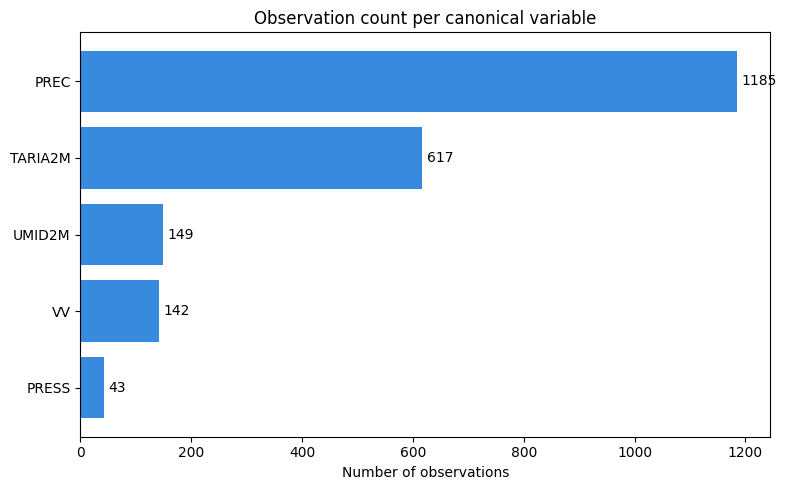

In [16]:
import matplotlib.pyplot as plt

var_counts = long_full['variable'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(var_counts.index, var_counts.values, color='#378ADD')

ax.set_xlabel('Number of observations')
ax.set_title('Observation count per canonical variable')
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

## Step 5 — Aggregate to one row per station

For each (station, variable) we keep the reading with the **latest UTC timestamp**, then
pivot to wide format with `<VAR>_value` / `<VAR>_dt` columns.

In [13]:
# latest reading per station + variable
long_full = long_full.sort_values('dt_utc')
latest = long_full.groupby(['station_id', 'variable'], as_index=False).last()

# station-level metadata (first non-null)
meta = (long_full.sort_values('dt_utc')
        .groupby('station_id', as_index=False)
        .agg({'station_name': 'first', 'lat': 'first', 'lon': 'first',
              'gestore': 'first', 'source': 'first'}))

# pivot values and timestamps separately, then join
val_wide = latest.pivot(index='station_id', columns='variable', values='value')
val_wide.columns = [f'{c}_value' for c in val_wide.columns]
dt_wide = latest.pivot(index='station_id', columns='variable', values='dt_utc')
dt_wide.columns = [f'{c}_dt' for c in dt_wide.columns]

wide = meta.merge(val_wide, on='station_id').merge(dt_wide, on='station_id')

# tidy column order: meta, then value/dt pairs per variable
ordered = ['station_id', 'station_name', 'lat', 'lon', 'gestore', 'source']
for var in CANON_VARS:
    ordered += [c for c in (f'{var}_value', f'{var}_dt') if c in wide.columns]
wide = wide[ordered]
print('Aggregated station rows:', len(wide))
wide.head()

Aggregated station rows: 752


,station_id,station_name,lat,lon,gestore,source,PREC_value,PREC_dt,TARIA2M_value,TARIA2M_dt,PRESS_value,PRESS_dt,VV_value,VV_dt,UMID2M_value,UMID2M_dt
0,ADRIATIC::MH_dpcn-marche_Acqualagna,Acqualagna,43.62819,12.68448,MeteoHub_dpcn-marche,ADRIATIC,0.0,2026-06-21 16:00:00+00:00,30.8,2026-06-21 16:00:00+00:00,NaN,NaT,NaN,NaT,NaN,NaT
1,ADRIATIC::MH_dpcn-marche_Agugliano,Agugliano,43.54330,13.38060,MeteoHub_dpcn-marche,ADRIATIC,0.0,2026-06-21 16:00:00+00:00,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT
2,ADRIATIC::MH_dpcn-marche_Amandola,Amandola,42.97638,13.35133,MeteoHub_dpcn-marche,ADRIATIC,0.0,2026-06-21 16:00:00+00:00,28.3,2026-06-21 16:00:00+00:00,NaN,NaT,NaN,NaT,NaN,NaT
3,ADRIATIC::MH_dpcn-marche_Ancona_Regione,Ancona Regione,43.61030,13.50830,MeteoHub_dpcn-marche,ADRIATIC,0.0,2026-06-21 16:00:00+00:00,28.5,2026-06-21 16:00:00+00:00,1011.0,2026-06-21 16:00:00+00:00,1.6,2026-06-21 16:00:00+00:00,NaN,NaT
4,ADRIATIC::MH_dpcn-marche_Ancona_Torrette,Ancona Torrette,43.61095,13.44980,MeteoHub_dpcn-marche,ADRIATIC,0.0,2026-06-21 16:00:00+00:00,29.8,2026-06-21 16:00:00+00:00,NaN,NaT,NaN,NaT,NaN,NaT


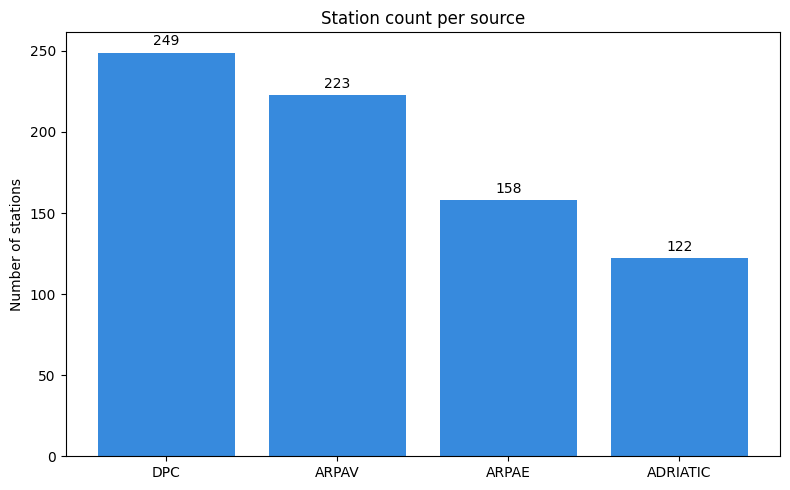

In [18]:
import matplotlib.pyplot as plt

station_counts = wide['source'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(station_counts.index, station_counts.values, color='#378ADD')

ax.set_ylabel('Number of stations')
ax.set_title('Station count per source')
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

## Step 6 — Save

In [15]:
out_path = OUTPUTS / 'DPC_stations_aggregated.csv'
wide.to_csv(out_path, index=False)
print('Saved ->', out_path)
print('Shape :', wide.shape)

Saved -> DPC_stations_aggregated.csv
Shape : (752, 16)
